# Notebook de regresión: análisis del conjunto transformado y comparación de modelos

Este notebook organiza el proceso completo de modelado de regresión de manera **clara, seccionada y explicada paso a paso**.

## Objetivos del notebook
- Cargar y revisar los datos.
- Dividir los datos en entrenamiento y prueba.
- Aplicar preprocesamiento con variables numéricas, ordinales y nominales.
- **Analizar cómo queda el conjunto de entrenamiento después del preprocesamiento**.
- Entrenar y evaluar varios modelos de regresión.
- Comparar los modelos con métricas y gráficos.
- Redactar conclusiones y recomendaciones finales.

## Modelos incluidos
1. Regresión lineal
2. Árbol de decisión
3. Random Forest
4. XGBoost

> Nota metodológica: el análisis detallado del conjunto transformado se realiza sobre el **set de entrenamiento**, porque es allí donde el preprocesador aprende la estructura de las variables. Luego el set de prueba se transforma con la misma lógica para evaluar el desempeño del modelo.

In [4]:
# =========================================================
# 1. IMPORTAR LIBRERÍAS
# =========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor, plot_importance

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Cargar datos

En esta sección se carga el dataset y se realiza una inspección inicial básica para verificar dimensión, primeras filas, tipos de datos y resumen estadístico.

In [5]:
# =========================================================
# 2. CARGAR DATOS
# =========================================================
ruta = '/content/drive/MyDrive/bootcamp_ia_2026-1/ds_salaries_limpia.csv'
df = pd.read_csv(ruta)

print("REVISION DE DATOS__________________________________")
print("Dimensión del dataset:", df.shape)
print("\nPrimeras filas:")
display(df.head())

print("\nInformación general:")
display(df.info())

print("\nResumen estadístico:")
display(df.describe().T)

REVISION DE DATOS__________________________________
Dimensión del dataset: (565, 9)

Primeras filas:


,work_year,experience_level,employment_type,job_title,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,MI,FT,Data Scientist,79833,DE,0,DE,L
1,2020,SE,FT,Machine Learning Scientist,260000,JP,0,JP,S
2,2020,SE,FT,Big Data Engineer,109024,GB,50,GB,M
3,2020,MI,FT,Product Data Analyst,20000,HN,0,HN,S
4,2020,SE,FT,Machine Learning Engineer,150000,US,50,US,L



Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 565 entries, 0 to 564
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           565 non-null    int64 
 1   experience_level    565 non-null    object
 2   employment_type     565 non-null    object
 3   job_title           565 non-null    object
 4   salary_in_usd       565 non-null    int64 
 5   employee_residence  565 non-null    object
 6   remote_ratio        565 non-null    int64 
 7   company_location    565 non-null    object
 8   company_size        565 non-null    object
dtypes: int64(3), object(6)
memory usage: 39.9+ KB


None


Resumen estadístico:


,count,mean,std,min,25%,50%,75%,max
work_year,565.0,2021.364602,0.698138,2020.0,2021.0,2021.0,2022.0,2022.0
salary_in_usd,565.0,110610.343363,72280.702792,2859.0,60757.0,100000.0,150000.0,600000.0
remote_ratio,565.0,69.911504,40.900666,0.0,50.0,100.0,100.0,100.0


## 3. Separar variables predictoras y variable objetivo

La variable objetivo es `salary_in_usd`.  
Las demás variables se utilizarán como entradas para el modelo.

In [6]:
# =========================================================
# 3. SEPARAR X e y
# =========================================================
X = df.drop('salary_in_usd', axis=1)
y = df['salary_in_usd']

print("Variables predictoras:", list(X.columns))
print("Variable objetivo: salary_in_usd")

Variables predictoras: ['work_year', 'experience_level', 'employment_type', 'job_title', 'employee_residence', 'remote_ratio', 'company_location', 'company_size']
Variable objetivo: salary_in_usd


## 4. Definir tipos de variables

Aquí se separan las variables según el tratamiento que recibirán en el preprocesamiento:

- **Numéricas**: pasan directamente.
- **Ordinales**: se codifican con un orden lógico.
- **Nominales**: se transforman con OneHotEncoder.

In [7]:
# =========================================================
# 4. DEFINIR TIPOS DE VARIABLES
# =========================================================
numericas = ['work_year']
ordinales = ['experience_level', 'company_size', 'remote_ratio']
nominales = ['employment_type', 'job_title', 'employee_residence', 'company_location']

print("VARIABLES NUMÉRICAS:", numericas)
print("VARIABLES ORDINALES:", ordinales)
print("VARIABLES NOMINALES:", nominales)

VARIABLES NUMÉRICAS: ['work_year']
VARIABLES ORDINALES: ['experience_level', 'company_size', 'remote_ratio']
VARIABLES NOMINALES: ['employment_type', 'job_title', 'employee_residence', 'company_location']


## 5. Dividir los datos en entrenamiento y prueba

La división se hace antes del preprocesamiento para evitar fuga de información.  
El conjunto de entrenamiento se usa para ajustar el preprocesador y entrenar los modelos.  
El conjunto de prueba se reserva para evaluar el desempeño final.

In [8]:
# =========================================================
# 5. DIVIDIR DATOS
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Forma de X_train:", X_train.shape)
print("Forma de X_test:", X_test.shape)
print("Forma de y_train:", y_train.shape)
print("Forma de y_test:", y_test.shape)

Forma de X_train: (452, 8)
Forma de X_test: (113, 8)
Forma de y_train: (452,)
Forma de y_test: (113,)


## 6. Crear el preprocesador

Se utilizará un `ColumnTransformer` para aplicar un tratamiento distinto a cada tipo de variable:

- `OrdinalEncoder` para variables con orden natural.
- `OneHotEncoder` para variables nominales.
- `passthrough` para la variable numérica.

In [9]:
# =========================================================
# 6. CREAR PREPROCESADOR
# =========================================================
preprocesador = ColumnTransformer(
    transformers=[
        (
            'ord',
            OrdinalEncoder(categories=[
                ['EN', 'MI', 'SE', 'EX'],   # experience_level
                ['S', 'M', 'L'],            # company_size
                [0, 50, 100]                # remote_ratio
            ]),
            ordinales
        ),
        (
            'nom',
            OneHotEncoder(drop='first', handle_unknown='ignore'),
            nominales
        ),
        (
            'num',
            'passthrough',
            numericas
        )
    ]
)

preprocesador

ColumnTransformer(transformers=[('ord',
                                 OrdinalEncoder(categories=[['EN', 'MI', 'SE',
                                                             'EX'],
                                                            ['S', 'M', 'L'],
                                                            [0, 50, 100]]),
                                 ['experience_level', 'company_size',
                                  'remote_ratio']),
                                ('nom',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore'),
                                 ['employment_type', 'job_title',
                                  'employee_residence', 'company_location']),
                                ('num', 'passthrough', ['work_year'])])

## 7. Transformar los datos

El preprocesador se ajusta solo con `X_train` y luego se aplica a `X_train` y `X_test`.

In [10]:
# =========================================================
# 7. TRANSFORMAR DATOS
# =========================================================
X_train_pre = preprocesador.fit_transform(X_train)
X_test_pre = preprocesador.transform(X_test)

print("TAMAÑOS DE DATOS TRANSFORMADOS______________________")
print("Forma de X_train transformado:", X_train_pre.shape)
print("Forma de X_test transformado:", X_test_pre.shape)

TAMAÑOS DE DATOS TRANSFORMADOS______________________
Forma de X_train transformado: (452, 143)
Forma de X_test transformado: (113, 143)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


## 8. Análisis del conjunto de entrenamiento transformado

Esta sección responde a una pregunta metodológica importante:

> Ya que el EDA inicial se hizo antes, ahora interesa analizar **cómo quedan los datos después del preprocesamiento**, es decir, cómo los va a ver el modelo.

### ¿Qué se analiza aquí?
- Tamaño final del conjunto transformado.
- Nombres de las variables generadas.
- Estadísticas descriptivas del conjunto transformado.
- Activación de columnas binarias.
- Relación de variables transformadas con la variable objetivo.
- Algunas verificaciones básicas para comparar la estructura train/test.

> Este análisis se centra en el **set de entrenamiento transformado**.

In [11]:
# =========================================================
# 8.1 CONVERTIR EL TRAIN TRANSFORMADO A DATAFRAME
# =========================================================
feature_names = preprocesador.get_feature_names_out()

X_train_pre_dense = X_train_pre.toarray() if hasattr(X_train_pre, "toarray") else X_train_pre
X_test_pre_dense = X_test_pre.toarray() if hasattr(X_test_pre, "toarray") else X_test_pre

X_train_pre_df = pd.DataFrame(X_train_pre_dense, columns=feature_names, index=X_train.index)
X_test_pre_df = pd.DataFrame(X_test_pre_dense, columns=feature_names, index=X_test.index)

print("Primeras filas del conjunto transformado de entrenamiento:")
display(X_train_pre_df.head())

Primeras filas del conjunto transformado de entrenamiento:


,ord__experience_level,ord__company_size,ord__remote_ratio,nom__employment_type_FL,nom__employment_type_FT,nom__employment_type_PT,nom__job_title_Analytics Engineer,nom__job_title_Applied Data Scientist,nom__job_title_Applied Machine Learning Scientist,nom__job_title_BI Data Analyst,...,nom__company_location_PL,nom__company_location_PT,nom__company_location_RO,nom__company_location_RU,nom__company_location_SG,nom__company_location_SI,nom__company_location_TR,nom__company_location_US,nom__company_location_VN,num__work_year
331,1.0,1.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2022.0
117,1.0,1.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2021.0
211,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2021.0
0,1.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2020.0
494,1.0,0.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2022.0


In [12]:
# =========================================================
# 8.2 NOMBRES DE VARIABLES GENERADAS
# =========================================================
print("Cantidad total de variables luego del preprocesamiento:", len(feature_names))
display(pd.DataFrame({"variable_transformada": feature_names}))

Cantidad total de variables luego del preprocesamiento: 143


,variable_transformada
0,ord__experience_level
1,ord__company_size
2,ord__remote_ratio
3,nom__employment_type_FL
4,nom__employment_type_FT
...,...
138,nom__company_location_SI
139,nom__company_location_TR
140,nom__company_location_US
141,nom__company_location_VN


### Interpretación esperada
- Las variables ordinales quedan codificadas como números enteros.
- Las variables nominales generan varias columnas binarias.
- La variable numérica pasa directamente.
- El número final de columnas suele aumentar bastante cuando hay muchas categorías.

In [13]:
# =========================================================
# 8.3 ESTADÍSTICAS DESCRIPTIVAS DEL TRAIN TRANSFORMADO
# =========================================================
resumen_transformado = X_train_pre_df.describe().T
display(resumen_transformado.head(20))
print("Total de variables resumidas:", resumen_transformado.shape[0])

,count,mean,std,min,25%,50%,75%,max
ord__experience_level,452.0,1.362832,0.805325,0.0,1.0,1.0,2.0,3.0
ord__company_size,452.0,1.190265,0.661982,0.0,1.0,1.0,2.0,2.0
ord__remote_ratio,452.0,1.393805,0.820879,0.0,1.0,2.0,2.0,2.0
nom__employment_type_FL,452.0,0.006637,0.081288,0.0,0.0,0.0,0.0,1.0
nom__employment_type_FT,452.0,0.966814,0.179320,0.0,1.0,1.0,1.0,1.0
nom__employment_type_PT,452.0,0.017699,0.132002,0.0,0.0,0.0,0.0,1.0
nom__job_title_Analytics Engineer,452.0,0.006637,0.081288,0.0,0.0,0.0,0.0,1.0
nom__job_title_Applied Data Scientist,452.0,0.008850,0.093759,0.0,0.0,0.0,0.0,1.0
nom__job_title_Applied Machine Learning Scientist,452.0,0.006637,0.081288,0.0,0.0,0.0,0.0,1.0
nom__job_title_BI Data Analyst,452.0,0.008850,0.093759,0.0,0.0,0.0,0.0,1.0


Total de variables resumidas: 143


In [14]:
# =========================================================
# 8.4 VERIFICAR COMPATIBILIDAD TRAIN / TEST
# =========================================================
print("Cantidad de columnas en train transformado:", X_train_pre_df.shape[1])
print("Cantidad de columnas en test transformado:", X_test_pre_df.shape[1])
print("¿Mismas columnas?:", list(X_train_pre_df.columns) == list(X_test_pre_df.columns))

Cantidad de columnas en train transformado: 143
Cantidad de columnas en test transformado: 143
¿Mismas columnas?: True


### Interpretación sugerida
Si train y test tienen el mismo número de columnas y en el mismo orden, entonces el preprocesamiento quedó consistente.  
No significa que ambos conjuntos tengan exactamente la misma distribución, pero sí que se representaron con la misma estructura.

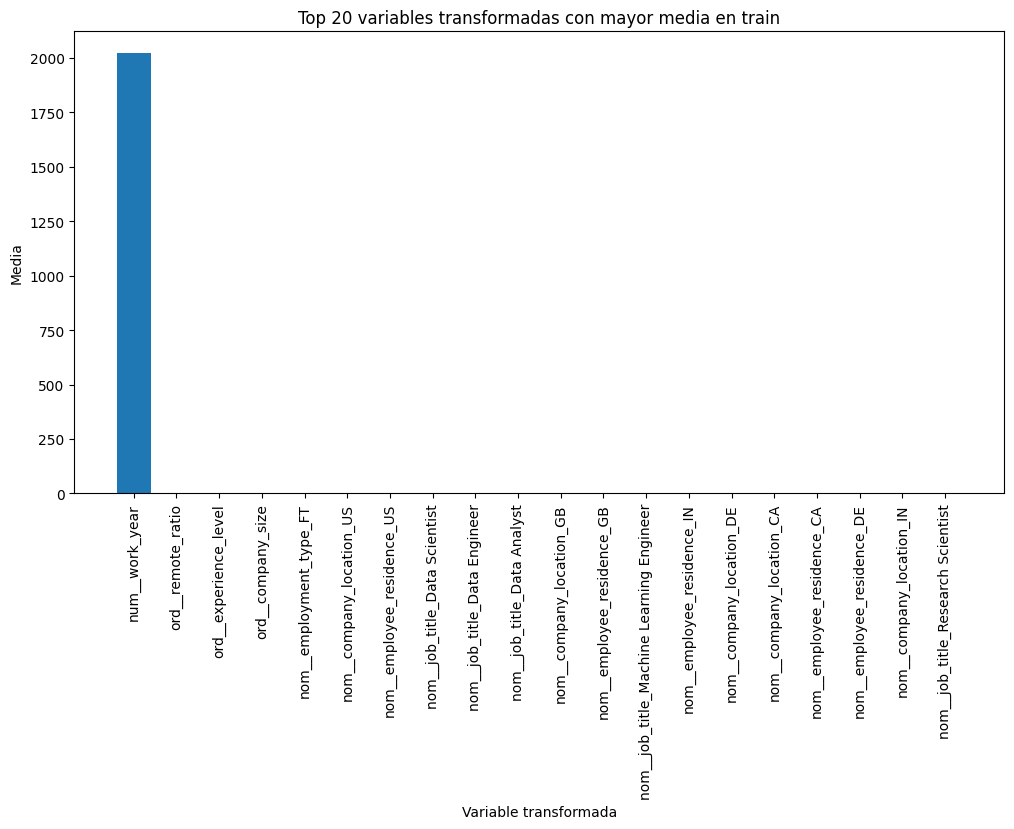

,media
num__work_year,2021.378319
ord__remote_ratio,1.393805
ord__experience_level,1.362832
ord__company_size,1.190265
nom__employment_type_FT,0.966814
nom__company_location_US,0.570796
nom__employee_residence_US,0.530973
nom__job_title_Data Scientist,0.225664
nom__job_title_Data Engineer,0.216814
nom__job_title_Data Analyst,0.150442


In [15]:
# =========================================================
# 8.5 ACTIVACIÓN DE VARIABLES TRANSFORMADAS
# =========================================================
activacion = X_train_pre_df.mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(activacion.head(20).index, activacion.head(20).values)
plt.title('Top 20 variables transformadas con mayor media en train')
plt.xlabel('Variable transformada')
plt.ylabel('Media')
plt.xticks(rotation=90)
plt.show()

display(activacion.head(20).to_frame("media"))

### ¿Cómo se interpreta este gráfico?
- En variables binarias del tipo one-hot, la media representa el **porcentaje de activación** de la categoría.
- En variables ordinales o numéricas, la media debe interpretarse según la escala usada.
- Este gráfico ayuda a ver qué columnas transformadas tienen más presencia dentro del conjunto de entrenamiento.

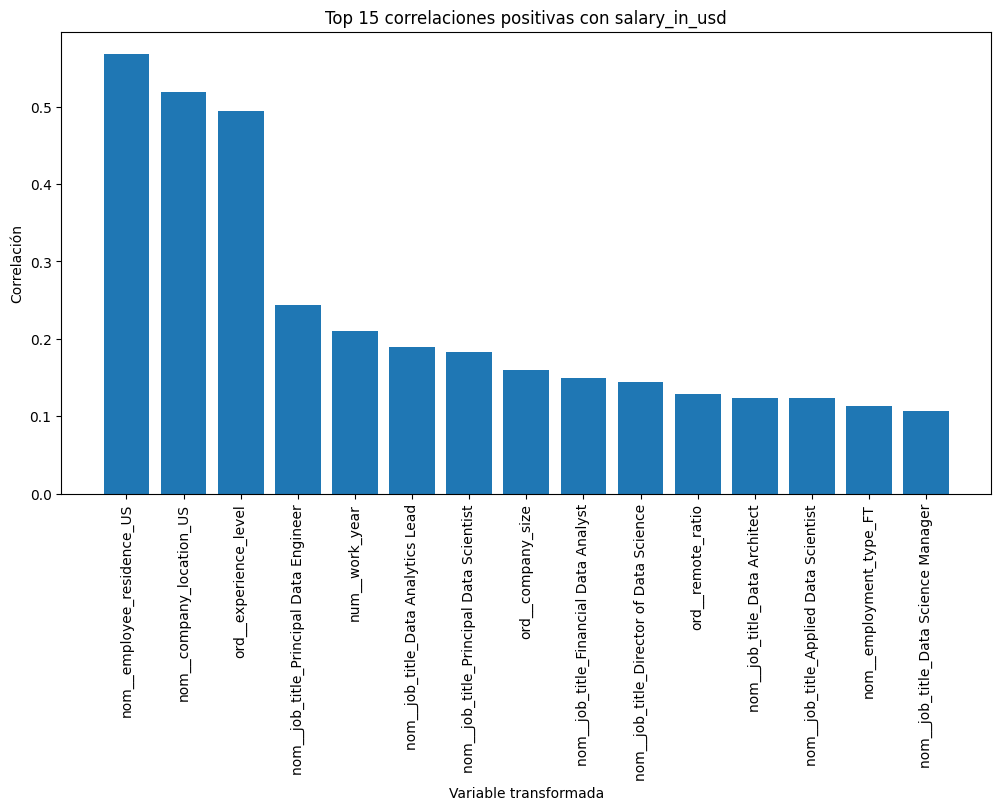

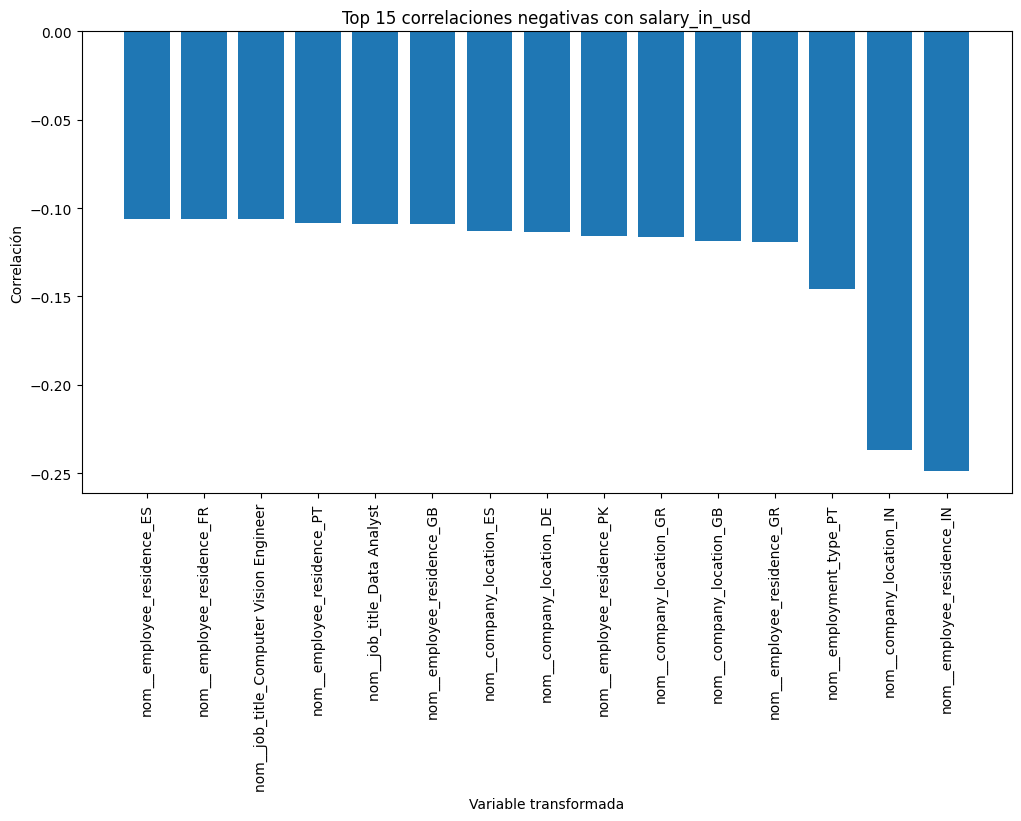

,correlacion_con_salary
salary_in_usd,1.000000
nom__employee_residence_US,0.568585
nom__company_location_US,0.518590
ord__experience_level,0.494653
nom__job_title_Principal Data Engineer,0.243468
num__work_year,0.209971
nom__job_title_Data Analytics Lead,0.189765
nom__job_title_Principal Data Scientist,0.182447
ord__company_size,0.159909
nom__job_title_Financial Data Analyst,0.149807


,correlacion_con_salary
nom__employee_residence_ES,-0.105934
nom__employee_residence_FR,-0.106103
nom__job_title_Computer Vision Engineer,-0.106151
nom__employee_residence_PT,-0.108627
nom__job_title_Data Analyst,-0.108770
nom__employee_residence_GB,-0.108972
nom__company_location_ES,-0.113023
nom__company_location_DE,-0.113311
nom__employee_residence_PK,-0.115743
nom__company_location_GR,-0.116213


In [16]:
# =========================================================
# 8.6 CORRELACIÓN DE VARIABLES TRANSFORMADAS CON LA VARIABLE OBJETIVO
# =========================================================
train_transformado_con_y = X_train_pre_df.copy()
train_transformado_con_y['salary_in_usd'] = y_train.values

corr_target = train_transformado_con_y.corr(numeric_only=True)['salary_in_usd'].sort_values(ascending=False)

top_positivas = corr_target.drop('salary_in_usd').head(15)
top_negativas = corr_target.drop('salary_in_usd').tail(15)

plt.figure(figsize=(12, 6))
plt.bar(top_positivas.index, top_positivas.values)
plt.title('Top 15 correlaciones positivas con salary_in_usd')
plt.xlabel('Variable transformada')
plt.ylabel('Correlación')
plt.xticks(rotation=90)
plt.show()

plt.figure(figsize=(12, 6))
plt.bar(top_negativas.index, top_negativas.values)
plt.title('Top 15 correlaciones negativas con salary_in_usd')
plt.xlabel('Variable transformada')
plt.ylabel('Correlación')
plt.xticks(rotation=90)
plt.show()

display(corr_target.head(15).to_frame("correlacion_con_salary"))
display(corr_target.tail(15).to_frame("correlacion_con_salary"))

### Lectura metodológica
Este análisis no reemplaza el EDA original del negocio, sino que muestra qué variables transformadas parecen tener mayor relación lineal con la variable objetivo dentro del espacio que usará el modelo.

Aquí hay que tener cuidado:
- una correlación alta no implica causalidad,
- en variables one-hot la interpretación es técnica,
- sirve para inspeccionar la representación del dato procesado.

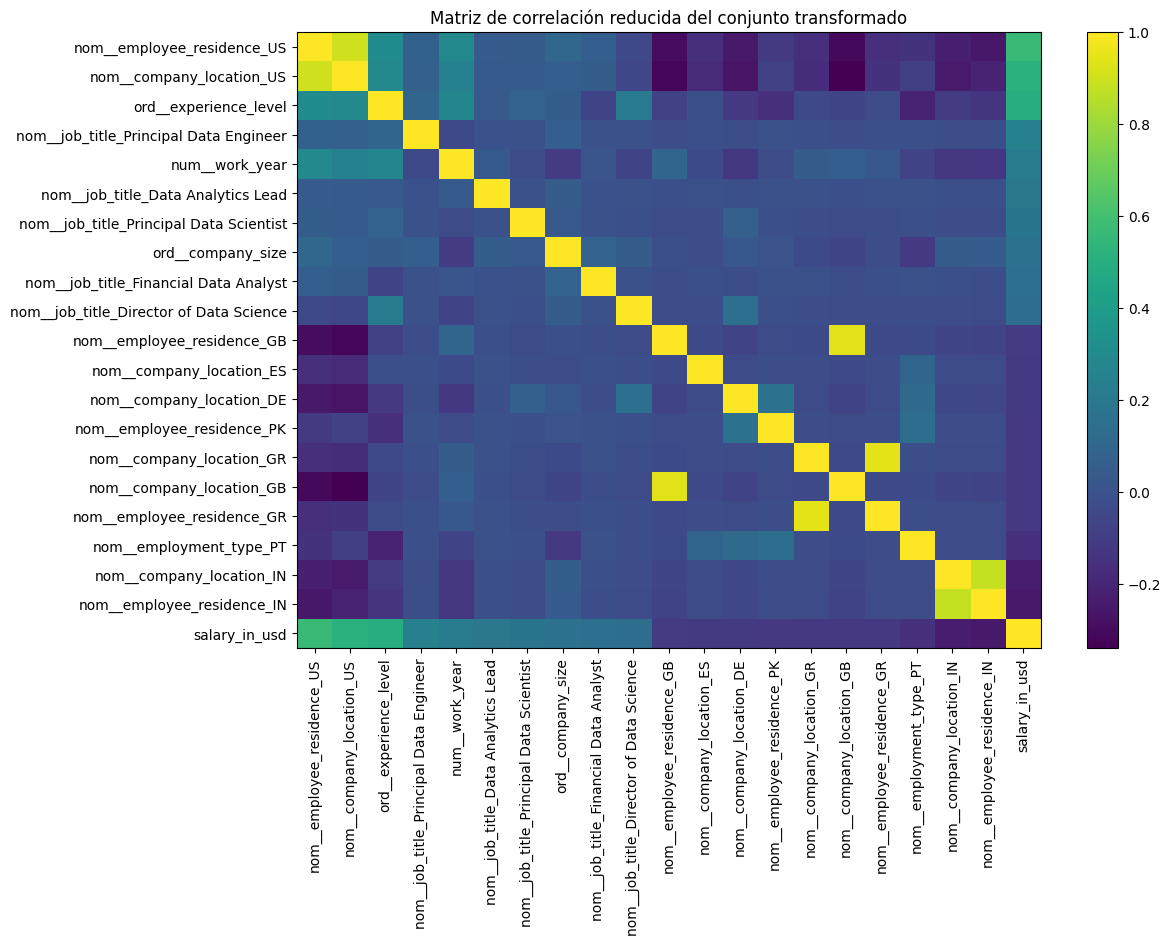

,nom__employee_residence_US,nom__company_location_US,ord__experience_level,nom__job_title_Principal Data Engineer,num__work_year,nom__job_title_Data Analytics Lead,nom__job_title_Principal Data Scientist,ord__company_size,nom__job_title_Financial Data Analyst,nom__job_title_Director of Data Science,...,nom__company_location_ES,nom__company_location_DE,nom__employee_residence_PK,nom__company_location_GR,nom__company_location_GB,nom__employee_residence_GR,nom__employment_type_PT,nom__company_location_IN,nom__employee_residence_IN,salary_in_usd
nom__employee_residence_US,1.000000,0.904719,0.308181,0.076825,0.289482,0.044256,0.057015,0.102821,0.062657,-0.045935,...,-0.160039,-0.246362,-0.112530,-0.151655,-0.312999,-0.160039,-0.142821,-0.222880,-0.251954,0.568585
nom__company_location_US,0.904719,1.000000,0.291100,0.070881,0.248850,0.040832,0.048976,0.060239,0.057810,-0.055646,...,-0.173459,-0.267020,-0.079231,-0.164372,-0.339245,-0.143070,-0.086998,-0.241569,-0.213279,0.518590
ord__experience_level,0.308181,0.291100,1.000000,0.098615,0.275790,0.037297,0.083771,0.053223,-0.071506,0.212023,...,-0.011748,-0.116951,-0.152882,-0.044601,-0.061578,-0.030447,-0.206550,-0.108187,-0.131338,0.494653
nom__job_title_Principal Data Engineer,0.076825,0.070881,0.098615,1.000000,-0.043703,-0.003849,-0.008645,0.058890,-0.005449,-0.009481,...,-0.012295,-0.018927,-0.008645,-0.011651,-0.024046,-0.012295,-0.010972,-0.017123,-0.019356,0.243468
num__work_year,0.289482,0.248850,0.275790,-0.043703,1.000000,0.041371,-0.026653,-0.101828,0.011464,-0.062013,...,-0.037906,-0.123798,-0.026653,0.058084,0.062137,0.025866,-0.071768,-0.127579,-0.126608,0.209971
nom__job_title_Data Analytics Lead,0.044256,0.040832,0.037297,-0.003849,0.041371,1.000000,-0.004980,0.057662,-0.003139,-0.005462,...,-0.007083,-0.010903,-0.004980,-0.006712,-0.013852,-0.007083,-0.006321,-0.009864,-0.011151,0.189765
nom__job_title_Principal Data Scientist,0.057015,0.048976,0.083771,-0.008645,-0.026653,-0.004980,1.000000,0.033546,-0.007051,-0.012267,...,-0.015908,0.071763,-0.011186,-0.015075,-0.031113,-0.015908,-0.014197,-0.022155,-0.025045,0.182447
ord__company_size,0.102821,0.060239,0.053223,0.058890,-0.101828,0.057662,0.033546,1.000000,0.081637,0.054329,...,-0.020533,0.024723,0.001557,-0.041012,-0.059929,-0.020533,-0.114747,0.056437,0.051234,0.159909
nom__job_title_Financial Data Analyst,0.062657,0.057810,-0.071506,-0.005449,0.011464,-0.003139,-0.007051,0.081637,1.000000,-0.007732,...,-0.010028,-0.015436,-0.007051,-0.009502,-0.019612,-0.010028,-0.008949,-0.013965,-0.015787,0.149807
nom__job_title_Director of Data Science,-0.045935,-0.055646,0.212023,-0.009481,-0.062013,-0.005462,-0.012267,0.054329,-0.007732,1.000000,...,-0.017446,0.149071,-0.012267,-0.016532,-0.034120,-0.017446,-0.015569,-0.024296,-0.027466,0.144474


In [17]:
# =========================================================
# 8.7 MATRIZ DE CORRELACIÓN REDUCIDA DE LAS VARIABLES MÁS RELACIONADAS CON LA META
# =========================================================
seleccion_corr = list(corr_target.drop('salary_in_usd').head(10).index) + list(corr_target.drop('salary_in_usd').tail(10).index)
seleccion_corr = list(dict.fromkeys(seleccion_corr))  # quitar duplicados conservando orden

corr_reducida = train_transformado_con_y[seleccion_corr + ['salary_in_usd']].corr(numeric_only=True)

plt.figure(figsize=(12, 8))
plt.imshow(corr_reducida, aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr_reducida.columns)), corr_reducida.columns, rotation=90)
plt.yticks(range(len(corr_reducida.index)), corr_reducida.index)
plt.title('Matriz de correlación reducida del conjunto transformado')
plt.show()

display(corr_reducida)

## 9. Funciones básicas de apoyo

Para mantener el notebook claro y con nivel de bootcamp, solo se reutilizan funciones muy básicas:

- una función para calcular métricas,
- una función para graficar **valores reales vs valores predichos**,
- una función para graficar **residuos** y su **histograma**.

El entrenamiento, la predicción y la interpretación de cada modelo se hacen **paso por paso en su propia sección**.


In [18]:
# =========================================================
# 9. FUNCIONES BÁSICAS
# =========================================================
def calcular_metricas(y_real, y_pred):
    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    r2 = r2_score(y_real, y_pred)
    return mae, rmse, r2


def grafico_reales_y_predichos(y_real, y_pred, titulo, n_mostrar=40):
    import numpy as np
    import matplotlib.pyplot as plt

    y_real = np.array(y_real)
    y_pred = np.array(y_pred)

    # tomar solo una cantidad de casos para que el gráfico no quede saturado
    n = min(n_mostrar, len(y_real))
    indices = np.arange(n)

    plt.figure(figsize=(10, 5))
    plt.plot(
        indices, y_real[:n],
        marker='o', linestyle='-', color='red',
        label='Valores reales'
    )
    plt.plot(
        indices, y_pred[:n],
        marker='o', linestyle='-', color='blue',
        label='Valores predichos'
    )

    plt.title(titulo)
    plt.xlabel('Observación')
    plt.ylabel('Valor')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()


def grafico_residuos(y_real, y_pred, titulo):
    import numpy as np
    import matplotlib.pyplot as plt

    y_real = np.array(y_real)
    y_pred = np.array(y_pred)
    residuos = y_real - y_pred

    plt.figure(figsize=(8, 5))
    plt.scatter(
        y_pred,
        residuos,
        color='mediumpurple',
        alpha=0.75,
        edgecolors='black',
        linewidths=0.3
    )
    plt.axhline(y=0, color='red', linestyle='--', linewidth=1.2)

    plt.title(titulo)
    plt.xlabel('Valores predichos')
    plt.ylabel('Residuo (real - predicho)')
    plt.grid(alpha=0.3)
    plt.show()


def histograma_residuos(y_real, y_pred, titulo):
    import numpy as np
    import matplotlib.pyplot as plt

    y_real = np.array(y_real)
    y_pred = np.array(y_pred)
    residuos = y_real - y_pred

    plt.figure(figsize=(8, 5))
    plt.hist(
        residuos,
        bins=25,
        color='mediumpurple',
        edgecolor='black',
        alpha=0.8
    )
    plt.axvline(x=0, color='red', linestyle='--', linewidth=1.2)

    plt.title(titulo)
    plt.xlabel('Residuo')
    plt.ylabel('Frecuencia')
    plt.grid(axis='y', alpha=0.3)
    plt.show()

# 10. Modelo 1: Regresión lineal

La regresión lineal busca modelar una relación lineal entre las variables de entrada y la variable objetivo.

## Hiperparámetros importantes
En `LinearRegression`, más que hiperparámetros complejos, interesa entender:
- que el modelo asume una relación aproximadamente lineal,
- que sirve como **línea base**,
- que es muy interpretable,
- pero puede quedarse corto si las relaciones son no lineales.

RESULTADOS - REGRESIÓN LINEAL
MAE: 35042.23816767666
RMSE: 57879.43157588891
R2: 0.30263874345856867


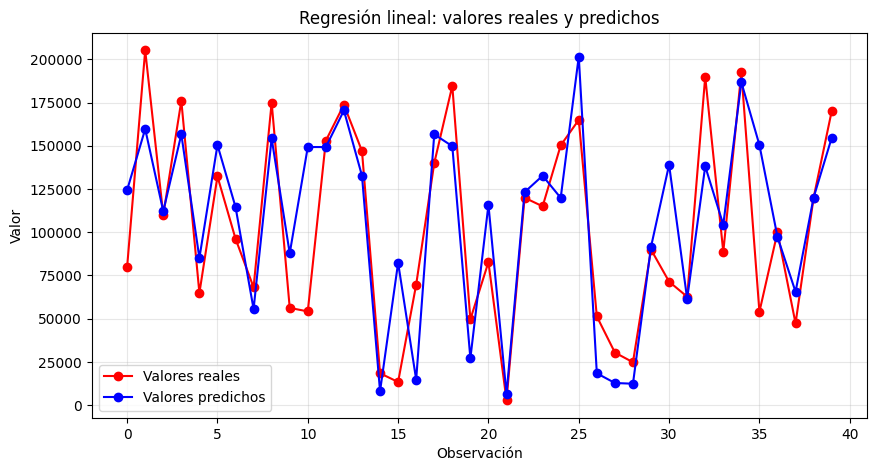

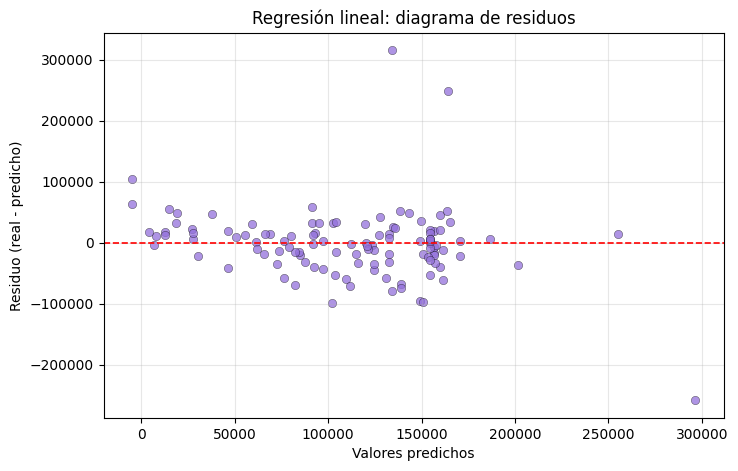

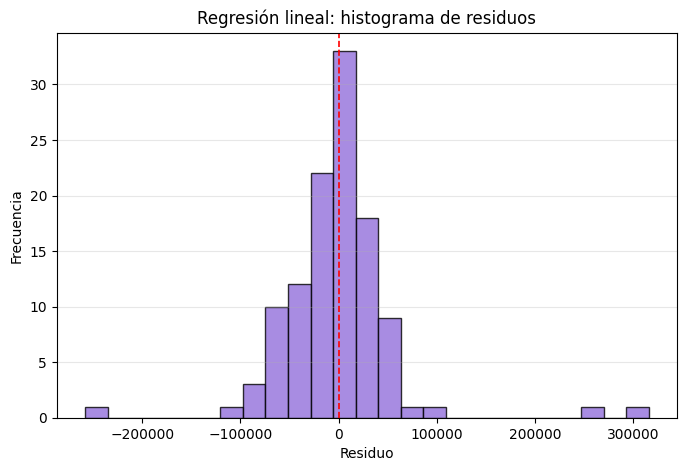

In [19]:
# =========================================================
# 10. REGRESIÓN LINEAL
# =========================================================

# Paso 1. Crear el modelo
modelo_lineal = LinearRegression()

# Paso 2. Entrenar el modelo con el conjunto transformado de entrenamiento
modelo_lineal.fit(X_train_pre, y_train)

# Paso 3. Generar predicciones sobre el conjunto de prueba
y_pred_lineal = modelo_lineal.predict(X_test_pre)

# Paso 4. Calcular métricas
mae_lineal, rmse_lineal, r2_lineal = calcular_metricas(y_test, y_pred_lineal)

# Paso 5. Mostrar resultados
print("RESULTADOS - REGRESIÓN LINEAL")
print("MAE:", mae_lineal)
print("RMSE:", rmse_lineal)
print("R2:", r2_lineal)

# Paso 6. Guardar resultados para la comparación final
resultados_lineal = {
    'Modelo': 'Regresión Lineal',
    'MAE': mae_lineal,
    'RMSE': rmse_lineal,
    'R2': r2_lineal
}

# Paso 7. Graficar resultados
grafico_reales_y_predichos(
    y_test,
    y_pred_lineal,
    'Regresión lineal: valores reales y predichos',
    n_mostrar=40
)

grafico_residuos(
    y_test,
    y_pred_lineal,
    'Regresión lineal: diagrama de residuos'
)

histograma_residuos(
    y_test,
    y_pred_lineal,
    'Regresión lineal: histograma de residuos'
)

### Qué observar

- En el gráfico **valores reales Y valores predichos**, SE COMPARAN PREDICHOS CON VALORES REALES
- En el gráfico de residuos, los puntos cercanos a cero indican errores pequeños.
- En el histograma de residuos, una mayor concentración alrededor de cero sugiere mejor ajuste.



# 11. Modelo 2: Árbol de decisión

El árbol de decisión divide el espacio de variables en reglas sucesivas.

## Hiperparámetros importantes
- `max_depth`: profundidad máxima del árbol.
- `min_samples_split`: mínimo de muestras para dividir un nodo.
- `min_samples_leaf`: mínimo de muestras por hoja.
- `random_state`: fija la reproducibilidad del resultado.

Un árbol muy profundo puede sobreajustarse; uno muy pequeño puede quedarse corto.

RESULTADOS - ÁRBOL DE DECISIÓN
MAE: 32878.62850911087
RMSE: 54426.95397095159
R2: 0.38335195372622266


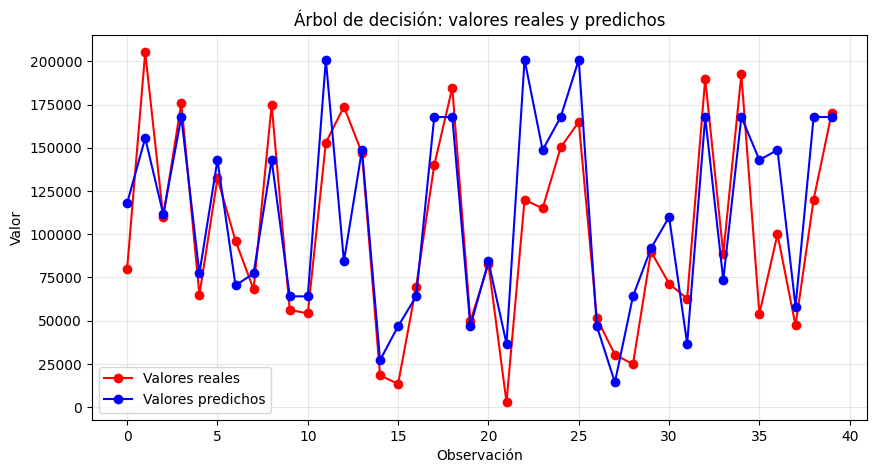

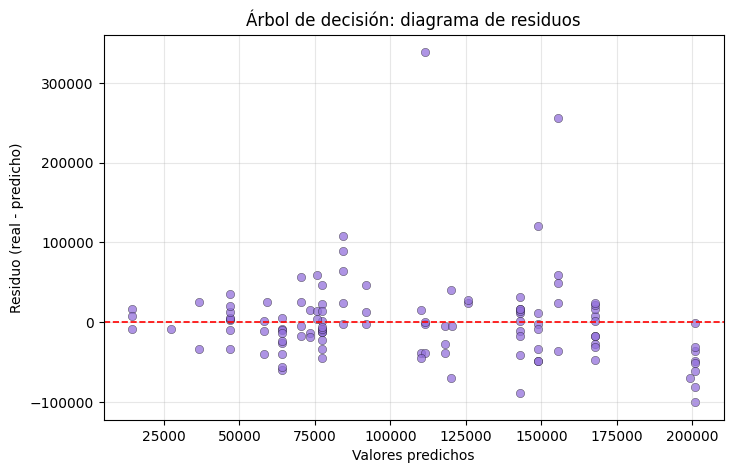

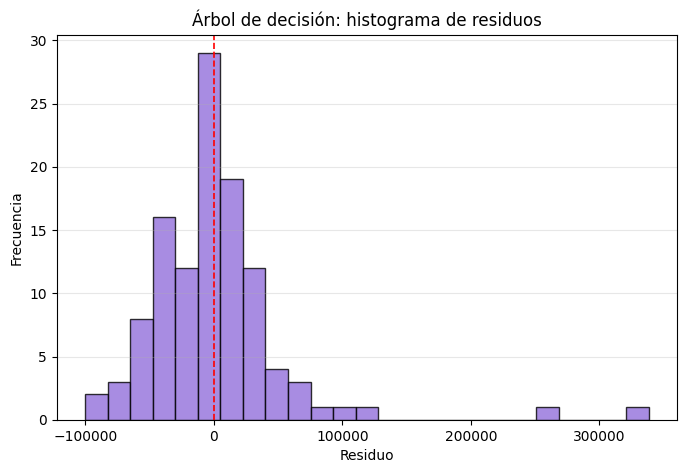

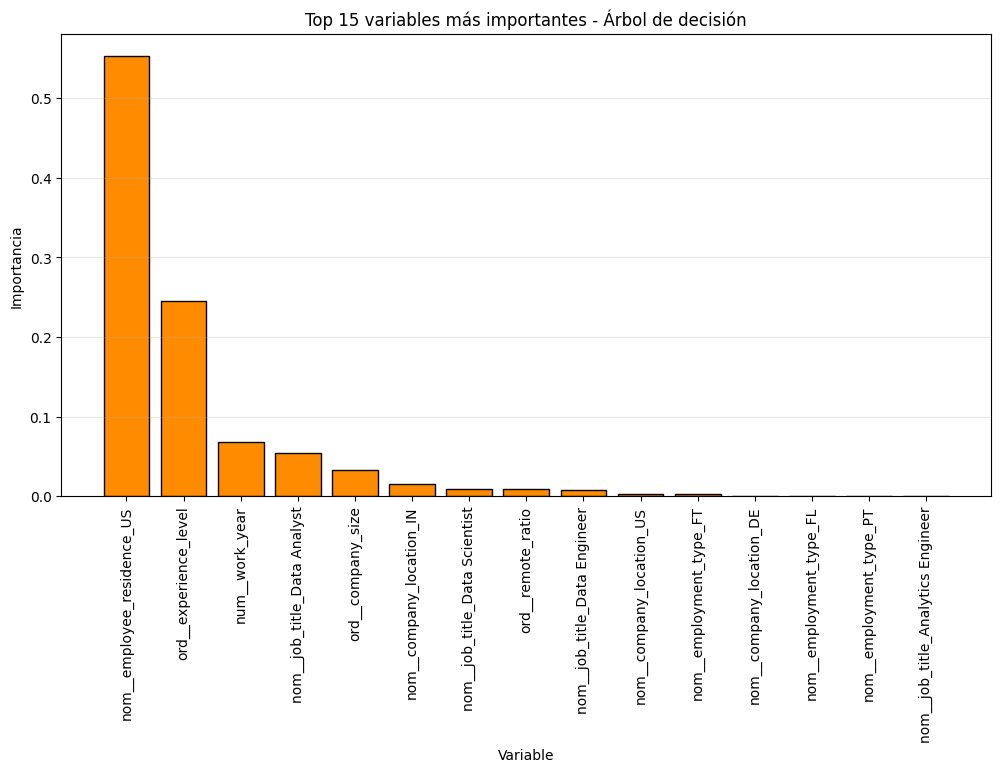

,importancia
nom__employee_residence_US,0.552838
ord__experience_level,0.245534
num__work_year,0.068517
nom__job_title_Data Analyst,0.054040
ord__company_size,0.033282
nom__company_location_IN,0.015568
nom__job_title_Data Scientist,0.008815
ord__remote_ratio,0.008503
nom__job_title_Data Engineer,0.008101
nom__company_location_US,0.002055


In [21]:
# =========================================================
# 11. ÁRBOL DE DECISIÓN
# =========================================================

# Paso 1. Crear el modelo con algunos hiperparámetros básicos
modelo_arbol = DecisionTreeRegressor(
    random_state=42,
    max_depth=6,
    min_samples_split=10,
    min_samples_leaf=5
)

# Paso 2. Entrenar el modelo
modelo_arbol.fit(X_train_pre, y_train)

# Paso 3. Generar predicciones
y_pred_arbol = modelo_arbol.predict(X_test_pre)

# Paso 4. Calcular métricas
mae_arbol, rmse_arbol, r2_arbol = calcular_metricas(y_test, y_pred_arbol)

# Paso 5. Mostrar resultados
print("RESULTADOS - ÁRBOL DE DECISIÓN")
print("MAE:", mae_arbol)
print("RMSE:", rmse_arbol)
print("R2:", r2_arbol)

# Paso 6. Guardar resultados para la comparación final
resultados_arbol = {
    'Modelo': 'Árbol de Decisión',
    'MAE': mae_arbol,
    'RMSE': rmse_arbol,
    'R2': r2_arbol
}

# Paso 7. Graficar resultados
grafico_reales_y_predichos(
    y_test,
    y_pred_arbol,
    'Árbol de decisión: valores reales y predichos',
    n_mostrar=40
)

grafico_residuos(
    y_test,
    y_pred_arbol,
    'Árbol de decisión: diagrama de residuos'
)

histograma_residuos(
    y_test,
    y_pred_arbol,
    'Árbol de decisión: histograma de residuos'
)

# OPCIONAL: importancia de variables en el árbol de decisión
importancias_arbol = pd.Series(
    modelo_arbol.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(
    importancias_arbol.head(15).index,
    importancias_arbol.head(15).values,
    color='darkorange',
    edgecolor='black'
)
plt.title('Top 15 variables más importantes - Árbol de decisión')
plt.xlabel('Variable')
plt.ylabel('Importancia')
plt.xticks(rotation=90)
plt.grid(axis='y', alpha=0.3)
plt.show()

display(importancias_arbol.head(15).to_frame('importancia'))

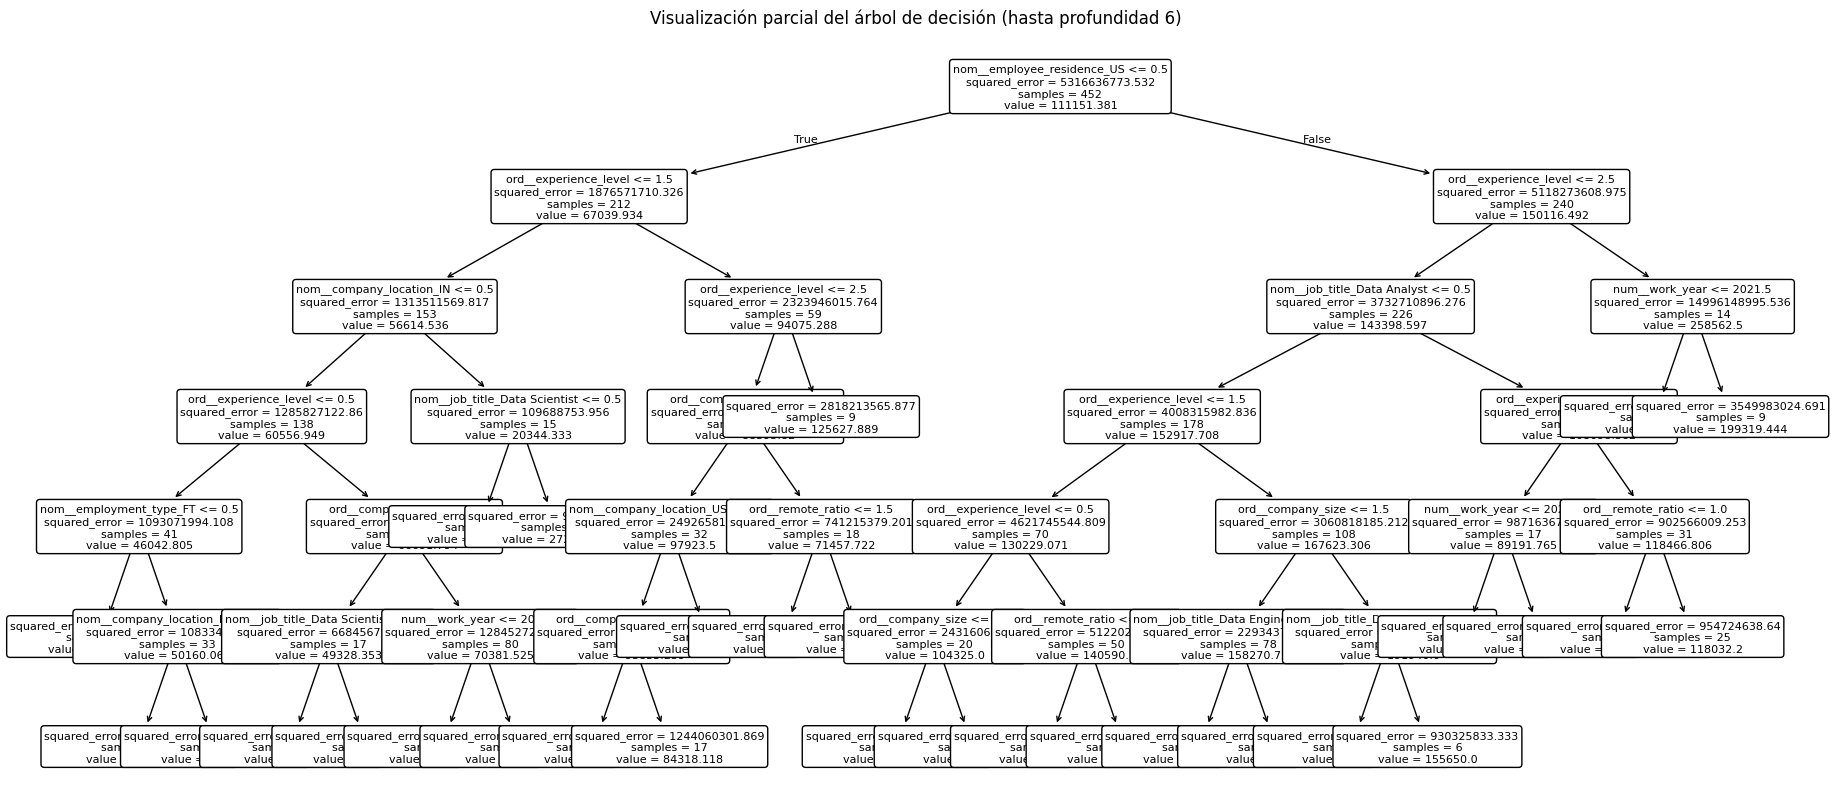

In [22]:
# =========================================================
# 11.1 VISUALIZACIÓN DEL ÁRBOL
# =========================================================
plt.figure(figsize=(22, 10))
plot_tree(
    modelo_arbol,
    feature_names=feature_names,
    filled=False,
    rounded=True,
    max_depth=6,
    fontsize=8
)
plt.title('Visualización parcial del árbol de decisión (hasta profundidad 6)')
plt.show()

### Qué observar

- En el gráfico **valores reales vs valores predichos**, COMPARAN
- En el gráfico de residuos, interesa revisar si la mayoría de errores se concentra cerca de cero.
- En el histograma de residuos, una distribución más concentrada alrededor de cero indica mejor comportamiento general.
- En el árbol, las primeras divisiones muestran qué variables ayudan más a separar los datos.
- En la gráfica de importancias, las variables superiores son las que más usa el árbol para tomar decisiones.


# 12. Modelo 3: Random Forest

Random Forest construye muchos árboles y combina sus resultados.

## Hiperparámetros importantes
- `n_estimators`: número de árboles del bosque.
- `max_depth`: profundidad máxima de cada árbol.
- `min_samples_split`: mínimo para dividir un nodo.
- `min_samples_leaf`: mínimo por hoja.
- `random_state`: reproducibilidad.

Suele mejorar frente a un solo árbol porque reduce varianza y controla mejor el sobreajuste.

RESULTADOS - RANDOM FOREST
MAE: 32547.497033087966
RMSE: 52155.43152701725
R2: 0.4337497758481742


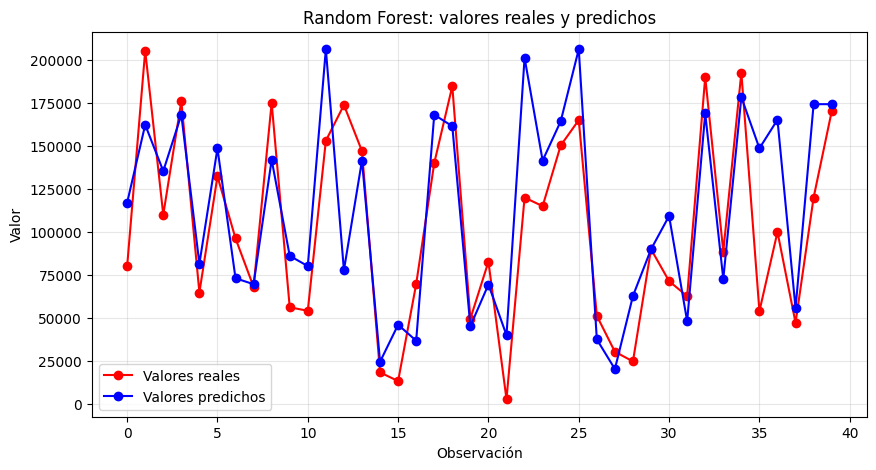

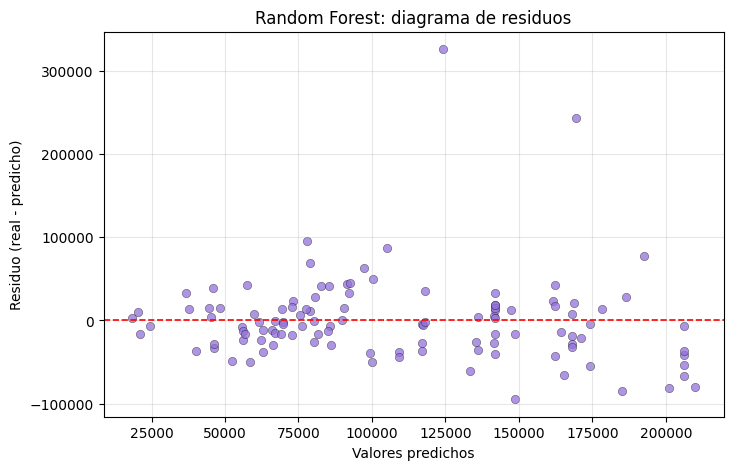

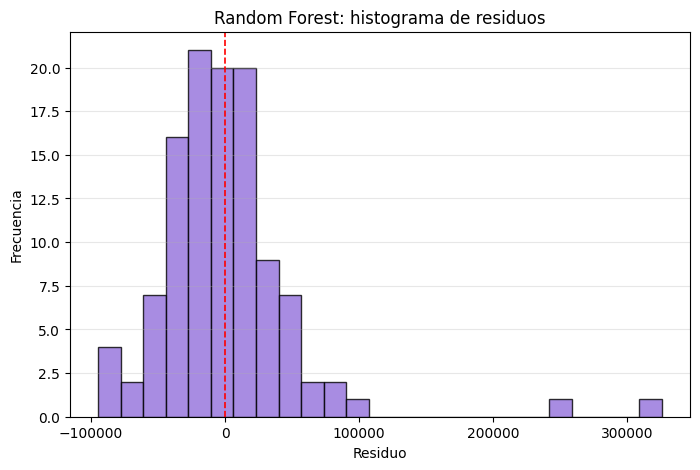

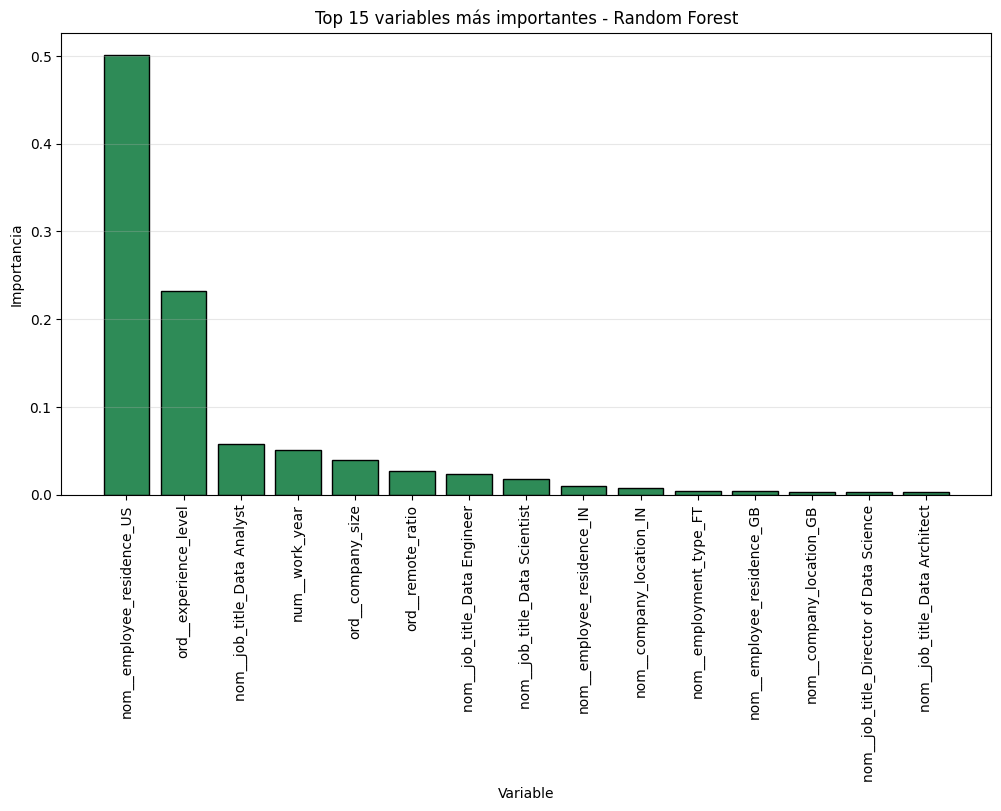

,importancia
nom__employee_residence_US,0.501469
ord__experience_level,0.232025
nom__job_title_Data Analyst,0.057716
num__work_year,0.050713
ord__company_size,0.039320
ord__remote_ratio,0.026407
nom__job_title_Data Engineer,0.023393
nom__job_title_Data Scientist,0.017545
nom__employee_residence_IN,0.009939
nom__company_location_IN,0.007057


In [23]:
# =========================================================
# 12. RANDOM FOREST
# =========================================================

# Paso 1. Crear el modelo
modelo_rf = RandomForestRegressor(
    random_state=42,
    n_estimators=150,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=4
)

# Paso 2. Entrenar el modelo
modelo_rf.fit(X_train_pre, y_train)

# Paso 3. Generar predicciones
y_pred_rf = modelo_rf.predict(X_test_pre)

# Paso 4. Calcular métricas
mae_rf, rmse_rf, r2_rf = calcular_metricas(y_test, y_pred_rf)

# Paso 5. Mostrar resultados
print("RESULTADOS - RANDOM FOREST")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2:", r2_rf)

# Paso 6. Guardar resultados
resultados_rf = {
    'Modelo': 'Random Forest',
    'MAE': mae_rf,
    'RMSE': rmse_rf,
    'R2': r2_rf
}

# Paso 7. Graficar resultados
grafico_reales_y_predichos(
    y_test,
    y_pred_rf,
    'Random Forest: valores reales y predichos',
    n_mostrar=40
)

grafico_residuos(
    y_test,
    y_pred_rf,
    'Random Forest: diagrama de residuos'
)

histograma_residuos(
    y_test,
    y_pred_rf,
    'Random Forest: histograma de residuos'
)

# Paso 8. Importancia de variables
importancias_rf = pd.Series(
    modelo_rf.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(
    importancias_rf.head(15).index,
    importancias_rf.head(15).values,
    color='seagreen',
    edgecolor='black'
)
plt.title('Top 15 variables más importantes - Random Forest')
plt.xlabel('Variable')
plt.ylabel('Importancia')
plt.xticks(rotation=90)
plt.grid(axis='y', alpha=0.3)
plt.show()

display(importancias_rf.head(15).to_frame('importancia'))


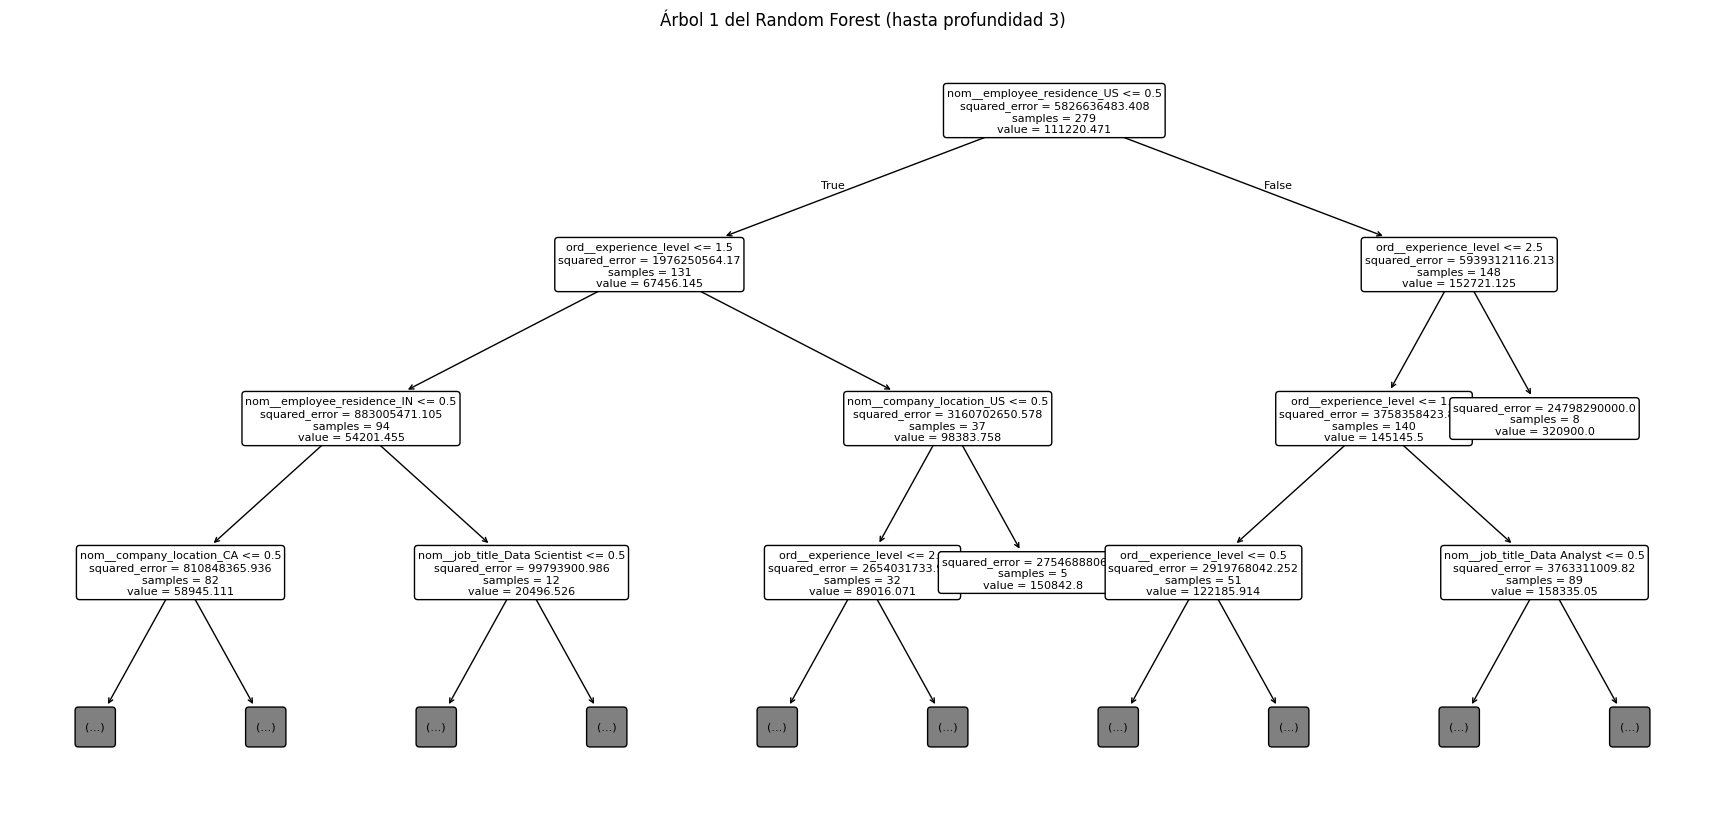

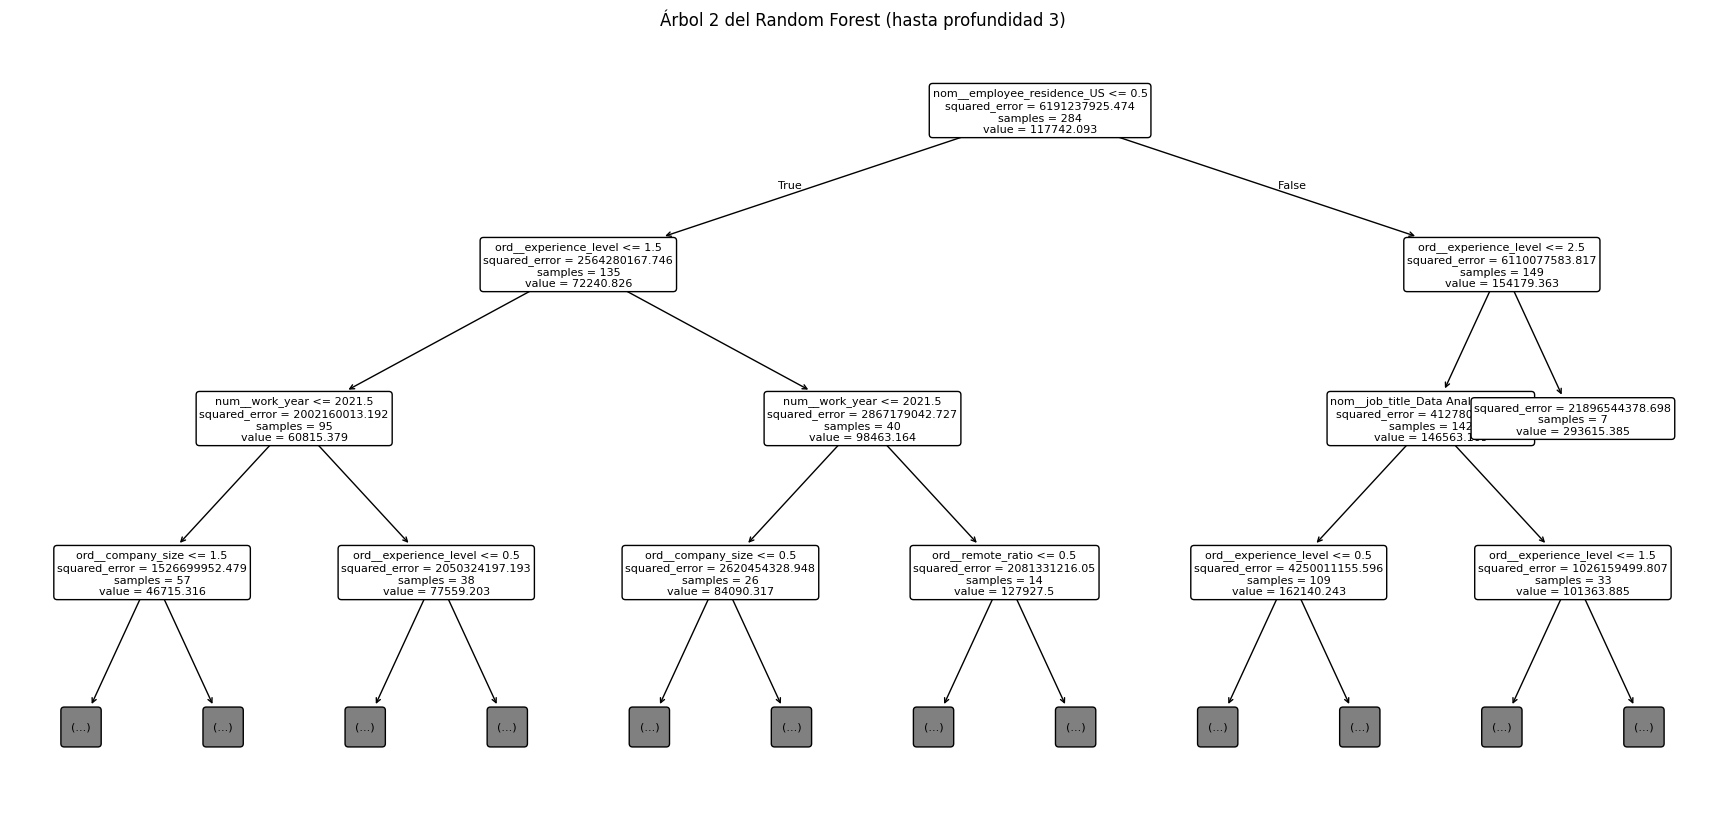

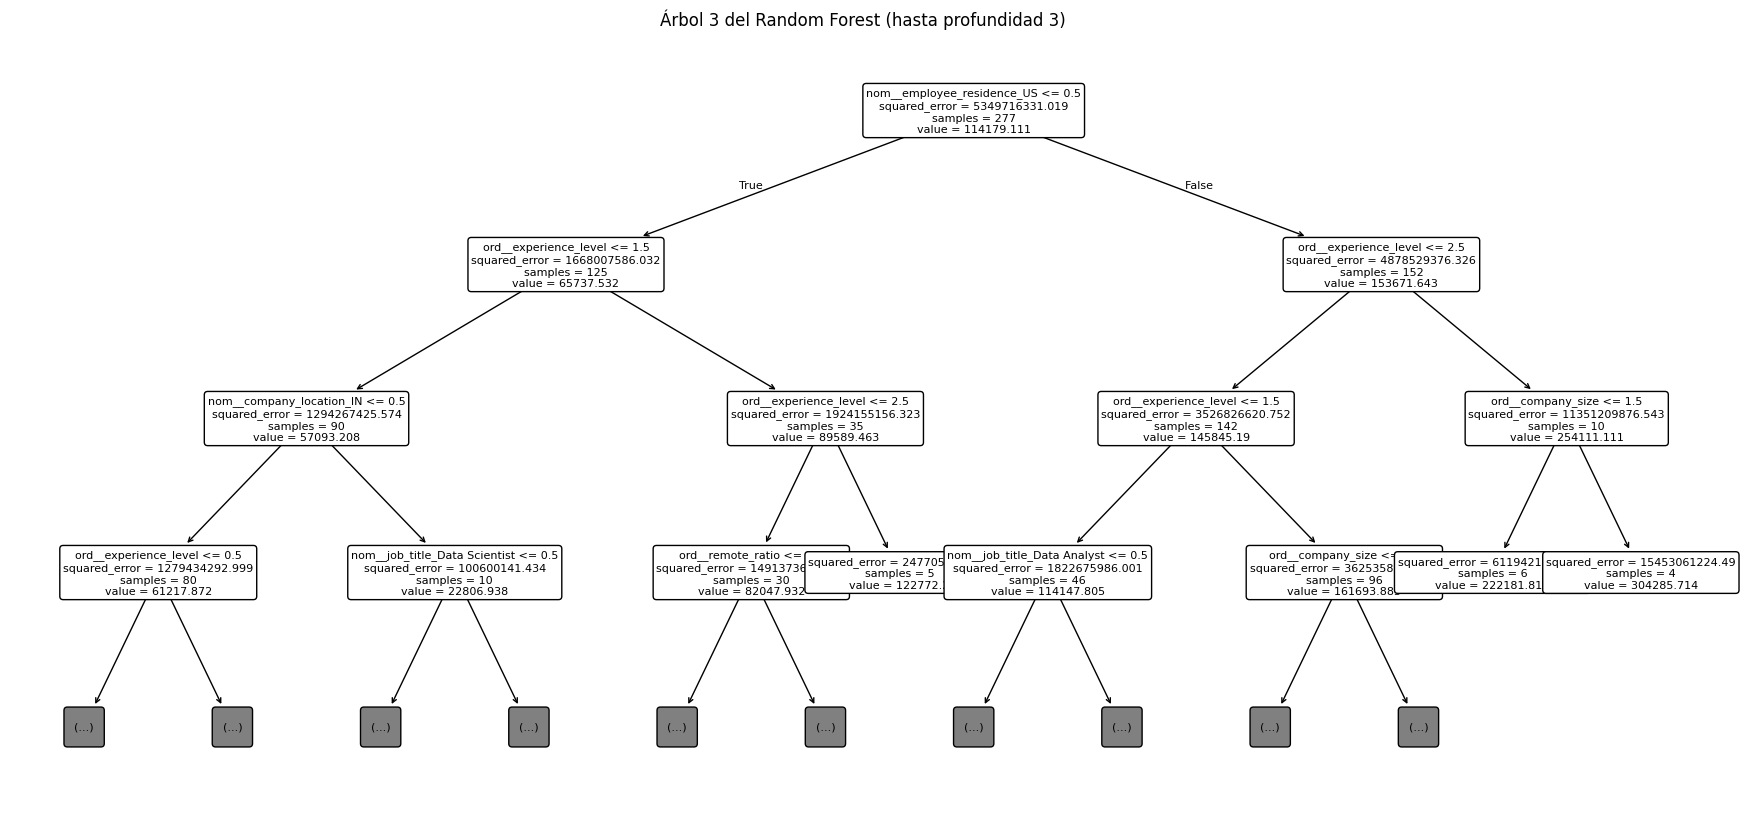

In [26]:

# cuántos árboles quieres mostrar
n_arboles_mostrar = 3

for i, arbol in enumerate(modelo_rf.estimators_[:n_arboles_mostrar]):
    plt.figure(figsize=(22, 10))
    plot_tree(
        arbol,
        feature_names=feature_names,
        filled=False,
        rounded=True,
        max_depth=3,
        fontsize=8
    )
    plt.title(f'Árbol {i+1} del Random Forest (hasta profundidad 3)')
    plt.show()

### Qué observar

- En el gráfico **valores reales vs valores predichos**,
- En el gráfico de residuos, interesa revisar si la dispersión baja y si aparecen menos errores extremos.
- En el histograma de residuos, una mayor concentración alrededor de cero sugiere mejores predicciones.
- En la visualización del árbol del bosque se observa una sola parte del modelo, ya que el Random Forest realmente combina muchos árboles.


# 13. Modelo 4: XGBoost

XGBoost es un modelo de boosting basado en árboles.  
Construye árboles secuenciales, donde cada nuevo árbol intenta corregir errores del anterior.

## Hiperparámetros importantes
- `n_estimators`: cantidad de árboles.
- `max_depth`: profundidad de cada árbol.
- `learning_rate`: qué tanto aporta cada árbol.
- `subsample`: fracción de filas usada por árbol.
- `colsample_bytree`: fracción de variables usada por árbol.
- `objective`: función objetivo del problema.

Es un modelo muy potente, pero requiere más ajuste que otros modelos.

RESULTADOS - XGBOOST
MAE: 28245.693359375
RMSE: 49989.2903730389
R2: 0.479808509349823


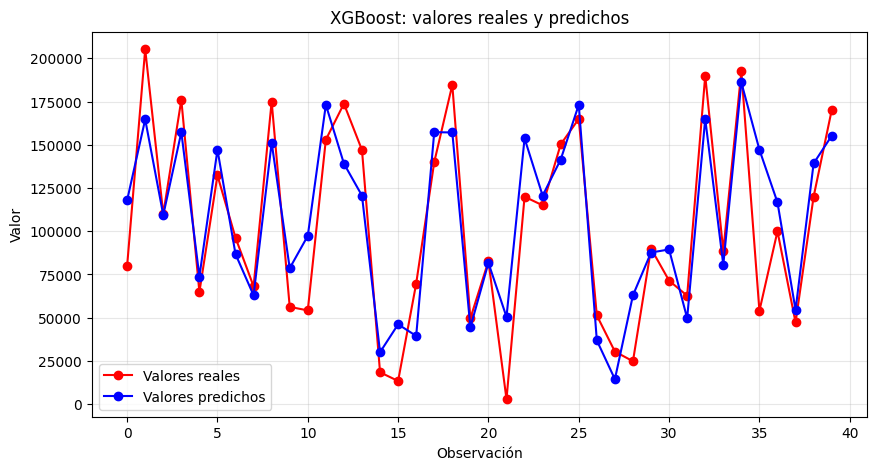

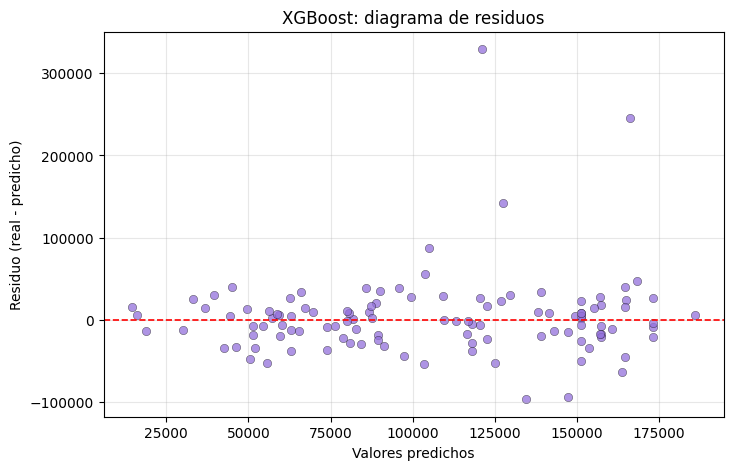

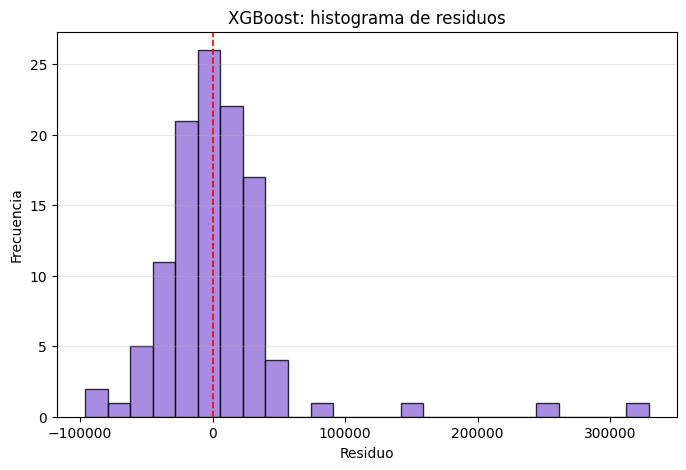

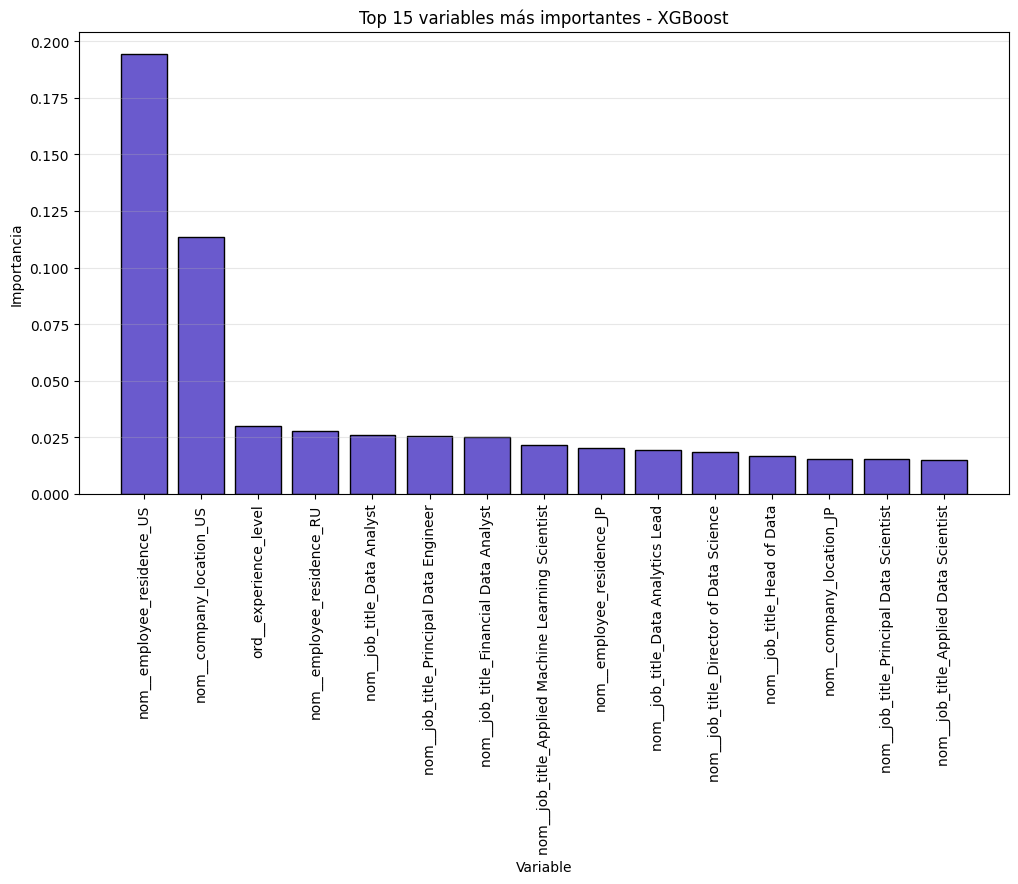

,importancia
nom__employee_residence_US,0.194424
nom__company_location_US,0.113566
ord__experience_level,0.029933
nom__employee_residence_RU,0.027978
nom__job_title_Data Analyst,0.025996
nom__job_title_Principal Data Engineer,0.025474
nom__job_title_Financial Data Analyst,0.024974
nom__job_title_Applied Machine Learning Scientist,0.021667
nom__employee_residence_JP,0.020162
nom__job_title_Data Analytics Lead,0.019176


In [28]:
# =========================================================
# 13. XGBOOST
# =========================================================

# Paso 1. Crear el modelo
modelo_xgb = XGBRegressor(
    random_state=42,
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror'
)

# Paso 2. Entrenar el modelo
modelo_xgb.fit(X_train_pre, y_train)

# Paso 3. Generar predicciones
y_pred_xgb = modelo_xgb.predict(X_test_pre)

# Paso 4. Calcular métricas
mae_xgb, rmse_xgb, r2_xgb = calcular_metricas(y_test, y_pred_xgb)

# Paso 5. Mostrar resultados
print("RESULTADOS - XGBOOST")
print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)
print("R2:", r2_xgb)

# Paso 6. Guardar resultados
resultados_xgb = {
    'Modelo': 'XGBoost',
    'MAE': mae_xgb,
    'RMSE': rmse_xgb,
    'R2': r2_xgb
}

# Paso 7. Graficar resultados
grafico_reales_y_predichos(
    y_test,
    y_pred_xgb,
    'XGBoost: valores reales y predichos',
    n_mostrar=40
)

grafico_residuos(
    y_test,
    y_pred_xgb,
    'XGBoost: diagrama de residuos'
)

histograma_residuos(
    y_test,
    y_pred_xgb,
    'XGBoost: histograma de residuos'
)


# Paso 8. Importancia de variables
importancias_xgb = pd.Series(
    modelo_xgb.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(
    importancias_xgb.head(15).index,
    importancias_xgb.head(15).values,
    color='slateblue',
    edgecolor='black'
)
plt.title('Top 15 variables más importantes - XGBoost')
plt.xlabel('Variable')
plt.ylabel('Importancia')
plt.xticks(rotation=90)
plt.grid(axis='y', alpha=0.3)
plt.show()

display(importancias_xgb.head(15).to_frame('importancia'))


### Qué observar

- En el gráfico **valores reales vs valores predichos**,
- En el gráfico de residuos, interesa verificar si la mayoría de errores queda alrededor de cero.
- En el histograma de residuos, una forma más concentrada alrededor de cero indica mejor ajuste.
- En la importancia de variables, se observan las características que más aportan a las predicciones del modelo.


# 14. Comparación final de modelos

En esta sección se reúnen todas las métricas para hacer una comparación directa entre los modelos.

In [30]:
# =========================================================
# 14. COMPARACIÓN FINAL
# =========================================================
resultados = pd.DataFrame([
    resultados_lineal,
    resultados_arbol,
    resultados_rf,
    resultados_xgb
])

resultados_ordenados = resultados.sort_values(by='R2', ascending=False).reset_index(drop=True)

print("COMPARACIÓN DE MODELOS______________________________")
display(resultados_ordenados)


COMPARACIÓN DE MODELOS______________________________


,Modelo,MAE,RMSE,R2
0,XGBoost,28245.693359,49989.290373,0.479809
1,Random Forest,32547.497033,52155.431527,0.433750
2,Árbol de Decisión,32878.628509,54426.953971,0.383352
3,Regresión Lineal,35042.238168,57879.431576,0.302639


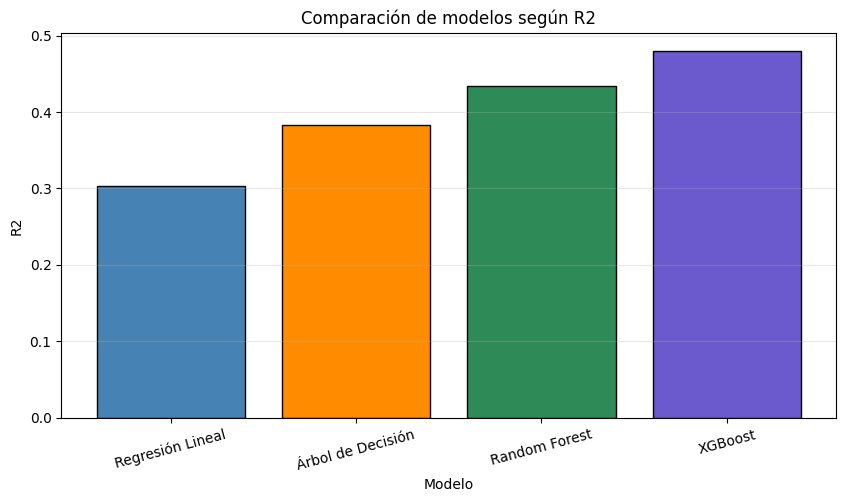

In [31]:
# =========================================================
# 14.1 GRÁFICO COMPARATIVO DE R2
# =========================================================
colores_modelos = ['steelblue', 'darkorange', 'seagreen', 'slateblue']

plt.figure(figsize=(10, 5))
plt.bar(resultados['Modelo'], resultados['R2'], color=colores_modelos, edgecolor='black')
plt.title('Comparación de modelos según R2')
plt.xlabel('Modelo')
plt.ylabel('R2')
plt.xticks(rotation=15)
plt.grid(axis='y', alpha=0.3)
plt.show()


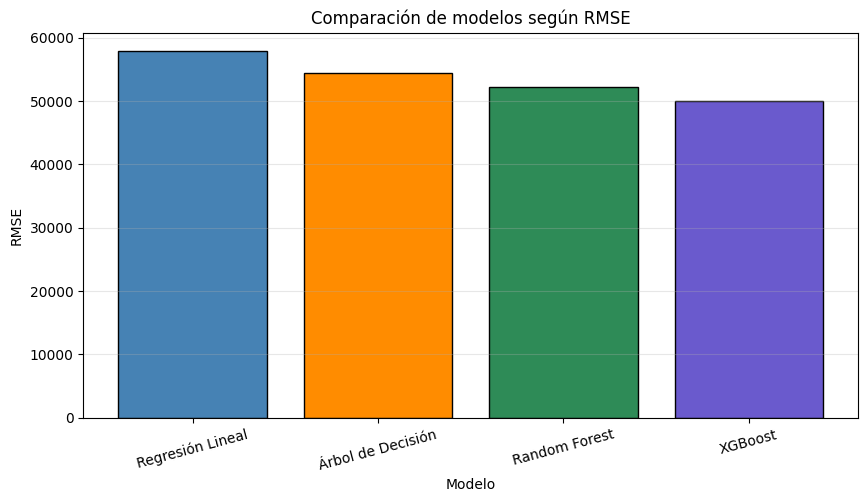

In [32]:
# =========================================================
# 14.2 GRÁFICO COMPARATIVO DE RMSE
# =========================================================
plt.figure(figsize=(10, 5))
plt.bar(resultados['Modelo'], resultados['RMSE'], color=colores_modelos, edgecolor='black')
plt.title('Comparación de modelos según RMSE')
plt.xlabel('Modelo')
plt.ylabel('RMSE')
plt.xticks(rotation=15)
plt.grid(axis='y', alpha=0.3)
plt.show()


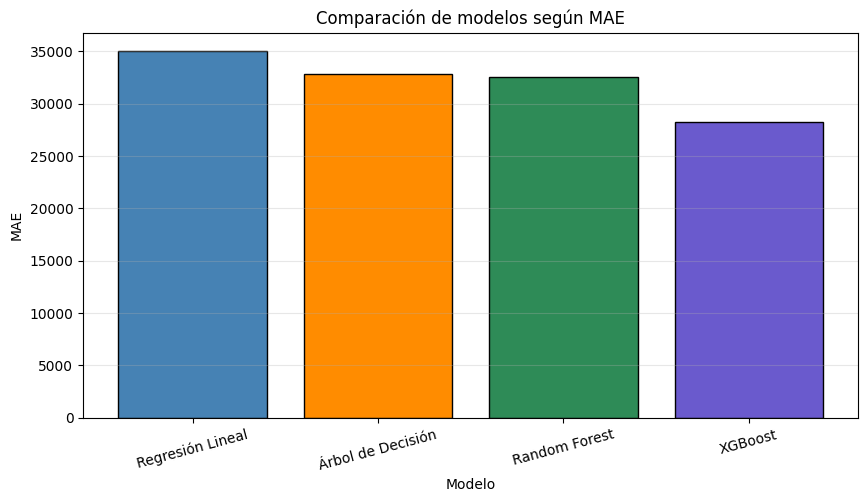

In [33]:
# =========================================================
# 14.3 GRÁFICO COMPARATIVO DE MAE
# =========================================================
plt.figure(figsize=(10, 5))
plt.bar(resultados['Modelo'], resultados['MAE'], color=colores_modelos, edgecolor='black')
plt.title('Comparación de modelos según MAE')
plt.xlabel('Modelo')
plt.ylabel('MAE')
plt.xticks(rotation=15)
plt.grid(axis='y', alpha=0.3)
plt.show()


# 15. Interpretación general de resultados

En esta parte se resume el comportamiento general de los modelos:

- un **R2** más alto indica mejor capacidad de explicación del salario,
- un **MAE** más bajo indica menor error promedio absoluto,
- un **RMSE** más bajo penaliza más los errores grandes.

La comparación debe considerar no solo la métrica final, sino también la interpretabilidad y el nivel del bootcamp.


In [34]:
# =========================================================
# 15.1 DESCRIPCIÓN AUTOMÁTICA DEL MEJOR MODELO
# =========================================================
mejor_modelo = resultados_ordenados.iloc[0]

print("MEJOR MODELO SEGÚN R2______________________________")
print(f"Modelo: {mejor_modelo['Modelo']}")
print(f"R2: {mejor_modelo['R2']:.4f}")
print(f"RMSE: {mejor_modelo['RMSE']:.4f}")
print(f"MAE: {mejor_modelo['MAE']:.4f}")

print("\nLECTURA GENERAL:")
print("- Revise si el modelo ganador también mantiene errores MAE y RMSE razonables.")
print("- Compare la forma de los gráficos reales vs predichos y residuos.")
print("- Si dos modelos quedan parecidos, conviene destacar el más fácil de explicar.")


MEJOR MODELO SEGÚN R2______________________________
Modelo: XGBoost
R2: 0.4798
RMSE: 49989.2904
MAE: 28245.6934

LECTURA GENERAL:
- Revise si el modelo ganador también mantiene errores MAE y RMSE razonables.
- Compare la forma de los gráficos reales vs predichos y residuos.
- Si dos modelos quedan parecidos, conviene destacar el más fácil de explicar.
